<a href="https://colab.research.google.com/github/munawirmt/prediction-models/blob/main/Naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NAIVE BAYES ALGORITHM MODEL(TEXT SPAM FILTER)

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#load text dataset from sklearn
#categorize only to keep it fast
categories= ['sci.space','rec.sport.baseball','comp.graphics','talk.politics.mideast']
newsgroups_train=fetch_20newsgroups(subset='train',categories=categories,shuffle=True)
newsgroups_test=fetch_20newsgroups(subset='test',categories=categories,shuffle=True)

print(f"Training samples:{len(newsgroups_train.data)}")
print(f"Testing samples:{len(newsgroups_test.data)}")


Training samples:2338
Testing samples:1556


In [ ]:
from numpy import vectorize
#convert text to samples
vectorizer=TfidfVectorizer()
X_train=vectorizer.fit_transform(newsgroups_train.data)
X_test=vectorizer.transform(newsgroups_test.data)

In [ ]:
#train
model=MultinomialNB()
model.fit(X_train,newsgroups_train.target)

MultinomialNB()

In [ ]:
#predict
y_pred=model.predict(X_test)
print(f"Accuracy:{accuracy_score(newsgroups_test.target,y_pred)*100:.2f}%")

Accuracy:95.69%


In [ ]:
#test my own sentance
my_text=["ISRO launched a new satellite into space"]
my_vec=vectorizer.transform(my_text)
print(f"Prediction:{model.predict(my_vec)}")
print(f"\nText: '{my_text[0]}' -> predicted as: {categories[model.predict(my_vec)[0]]}")

Prediction:[2]

Text: 'ISRO launched a new satellite into space' -> predicted as: comp.graphics


In [ ]:
#visualize the model
from sklearn import tree
model_tree=tree.DecisionTreeClassifier()
model_tree.fit(X_train,newsgroups_train.target)


DecisionTreeClassifier()

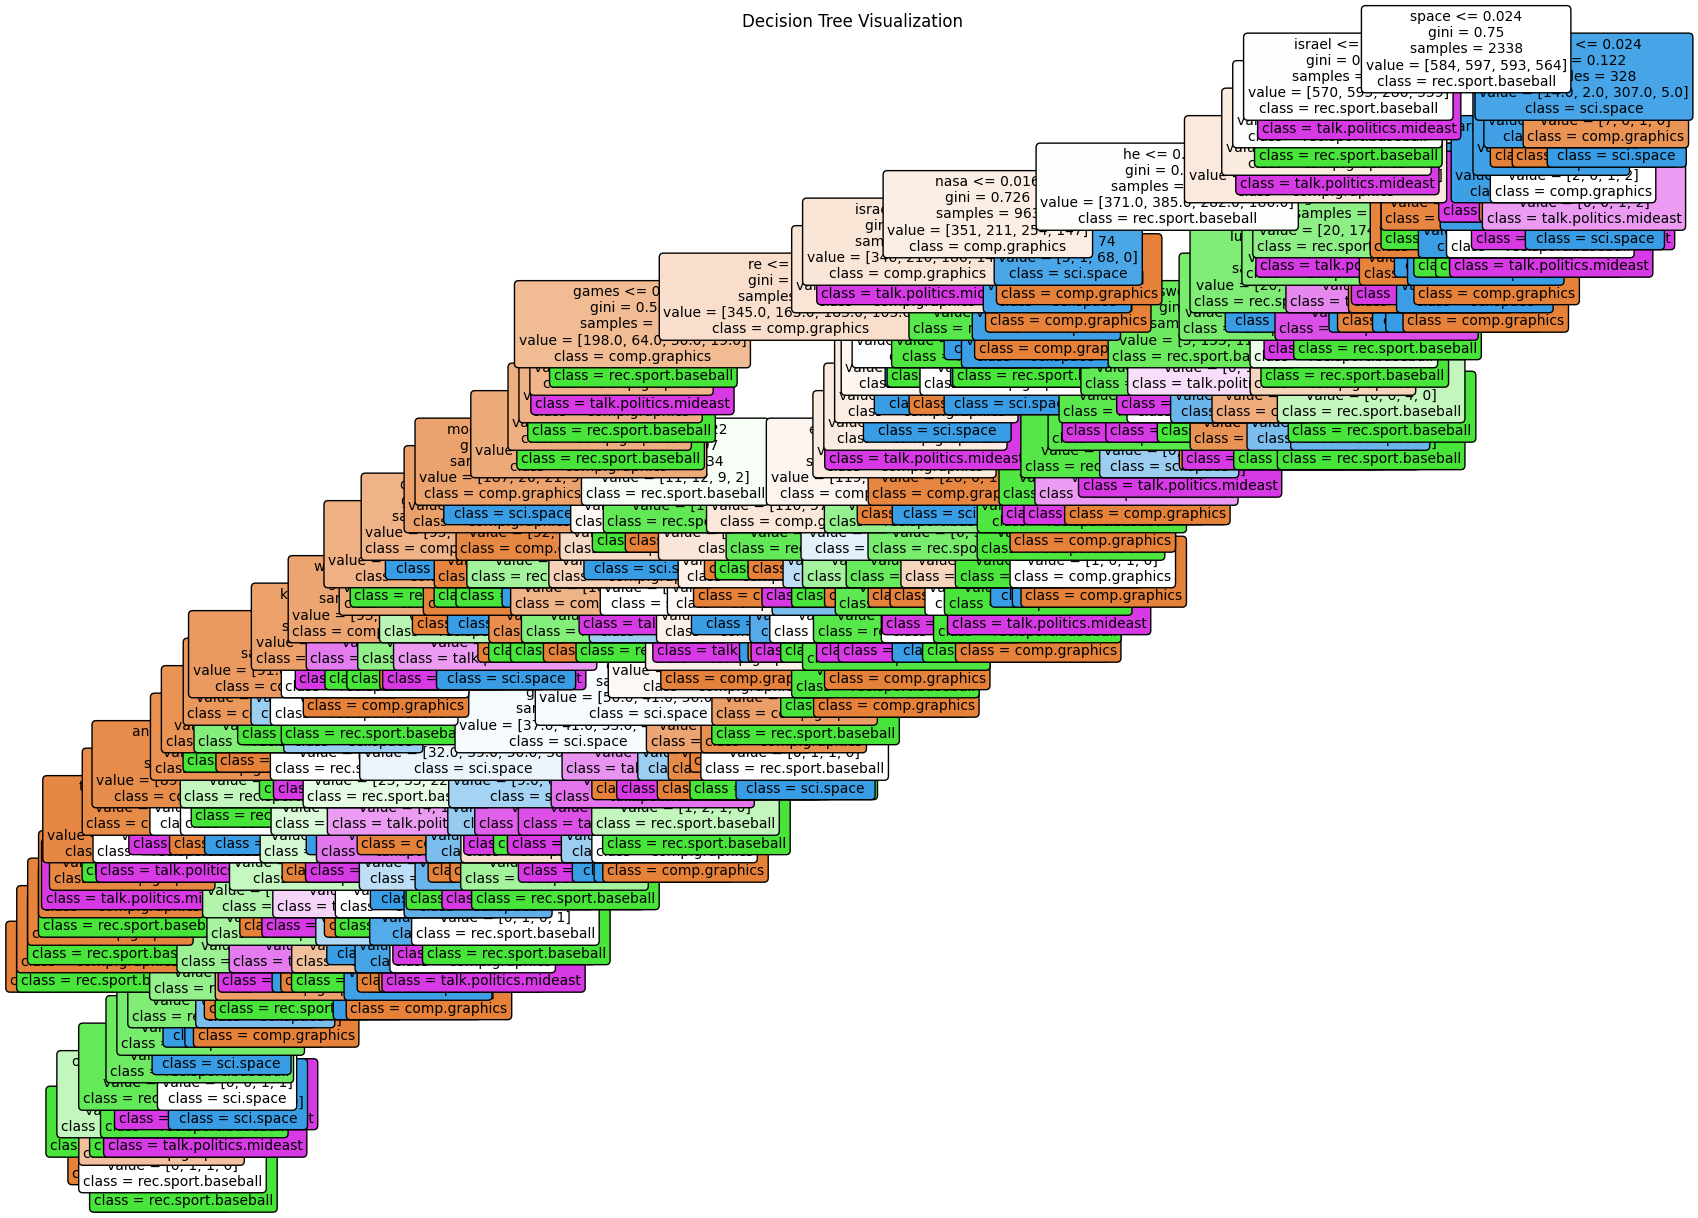

In [ ]:
import matplotlib.pyplot as plt

# Get feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()
# Get class names from the training data
class_names = newsgroups_train.target_names

plt.figure(figsize=(20, 15))
_ = tree.plot_tree(model_tree, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()